In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt


In [2]:
torch.set_num_threads(8)
device = torch.device("cpu")


In [3]:
data = np.load(r"C:\Users\ASUS\Downloads\PEMS08.npz\PEMS08.npz")
arr = data['data']
flow = arr[:,:,0]


In [4]:
split_index = int(0.8*len(flow))
train_flow = flow[:split_index]

mean = train_flow.mean()
std  = train_flow.std()

flow = (flow-mean)/std


In [5]:
SEQ_LEN = 48
PRED_LEN = 3

X=[]
Y=[]

for i in range(len(flow)-SEQ_LEN-PRED_LEN):
    X.append(flow[i:i+SEQ_LEN])
    Y.append(flow[i+SEQ_LEN:i+SEQ_LEN+PRED_LEN])

X=np.array(X)
Y=np.array(Y)


In [6]:
split=int(0.8*len(X))

X_train_full=X[:split]
Y_train_full=Y[:split]

X_test=X[split:]
Y_test=Y[split:]

val_split=int(0.9*len(X_train_full))

X_train=X_train_full[:val_split]
Y_train=Y_train_full[:val_split]

X_val=X_train_full[val_split:]
Y_val=Y_train_full[val_split:]


In [7]:
class TrafficDataset(Dataset):
    def __init__(self,X,Y):
        self.X=torch.tensor(X,dtype=torch.float32)
        self.Y=torch.tensor(Y,dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self,idx):
        return self.X[idx],self.Y[idx]

train_loader=DataLoader(TrafficDataset(X_train,Y_train),64,shuffle=True)
val_loader=DataLoader(TrafficDataset(X_val,Y_val),64)
test_loader=DataLoader(TrafficDataset(X_test,Y_test),64)


In [8]:
class CNNLLM(nn.Module):
    def __init__(self,sensors=170,hidden=128):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1,32,(3,3),padding=1),
            nn.ReLU(),
            nn.Conv2d(32,64,(3,3),padding=1),
            nn.ReLU(),
            nn.Conv2d(64,128,(3,3),padding=1),
            nn.ReLU()
        )

        self.project = nn.Linear(sensors*128, hidden)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=8,
            dim_feedforward=512,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=4)

        self.fc = nn.Linear(hidden, sensors*PRED_LEN)

    def forward(self,x):
        x=x.unsqueeze(1)
        x=self.cnn(x)

        B,C,T,S=x.shape
        x=x.permute(0,2,1,3).reshape(B,T,-1)

        x=self.project(x)
        x=self.transformer(x)

        out=self.fc(x[:,-1,:])
        return out.reshape(B,PRED_LEN,S)


In [9]:
model=CNNLLM().to(device)

optimizer=torch.optim.Adam(model.parameters(),lr=0.0001)
criterion=nn.MSELoss()

best_val=float("inf")
patience=10
counter=0

for epoch in range(100):

    model.train()
    train_loss=0

    for x,y in train_loader:
        x,y=x.to(device),y.to(device)

        optimizer.zero_grad()
        pred=model(x)
        loss=criterion(pred,y)
        loss.backward()
        optimizer.step()

        train_loss+=loss.item()

    train_loss/=len(train_loader)

    model.eval()
    val_loss=0
    with torch.no_grad():
        for x,y in val_loader:
            x,y=x.to(device),y.to(device)
            val_loss+=criterion(model(x),y).item()

    val_loss/=len(val_loader)

    print(epoch,train_loss,val_loss)

    if val_loss<best_val:
        best_val=val_loss
        counter=0
        torch.save(model.state_dict(),"best_cnnllm.pth")
    else:
        counter+=1
        if counter>=patience:
            print("Early stopping")
            break

model.load_state_dict(torch.load("best_cnnllm.pth"))


0 0.348710027463104 0.1622584128509397
1 0.08617664386161525 0.12089179018917291
2 0.06421099447492343 0.1089581039774677
3 0.054863568043234334 0.10428269912043343
4 0.04851125089905748 0.0978645641842614
5 0.043970286327214975 0.09283217698659586
6 0.040664083569945386 0.08992943054308063
7 0.038014104849292865 0.0864827219882737
8 0.03596991770414274 0.08332018886247407
9 0.03425752336335419 0.08161798435384812
10 0.032979677296915456 0.07778613609464272
11 0.03172384950318443 0.07463640128464802
12 0.030651921489790304 0.07312041431989359
13 0.02975334437443546 0.07056470328698987
14 0.02895900960177628 0.06932461674770583
15 0.02826294944209246 0.06842944034091804
16 0.027591558655177182 0.06632676736816116
17 0.026995348211248122 0.06503851375664058
18 0.02645837577680747 0.06373820401242246
19 0.025950299307185027 0.06248583016998094
20 0.025489382158538597 0.06184717287997837
21 0.024992474674511312 0.061771164648234844
22 0.024573730999854073 0.061040072296948536
23 0.02416730

<All keys matched successfully>

MAE: 18.025884109766547 RMSE: 26.87575907884963


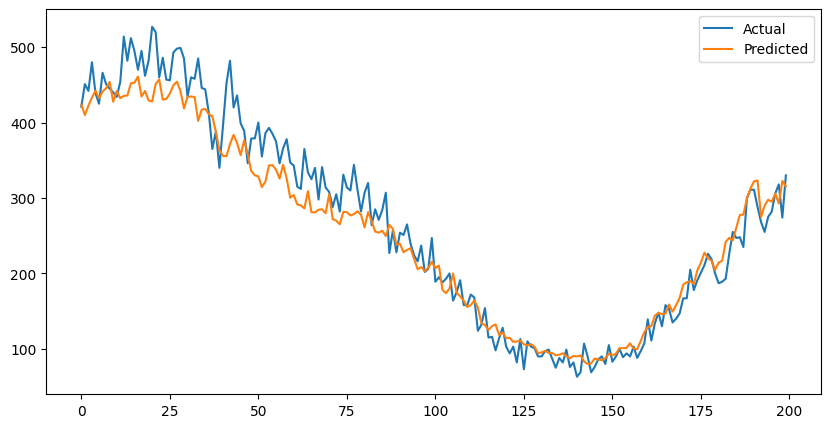

In [12]:
model.eval()

preds=[]
true=[]

with torch.no_grad():
    for x,y in test_loader:
        x=x.to(device)
        preds.append(model(x).cpu().numpy())
        true.append(y.numpy())

preds=np.concatenate(preds)
true=np.concatenate(true)

preds=preds*std+mean
true=true*std+mean

mae=mean_absolute_error(true.flatten(),preds.flatten())
rmse=np.sqrt(mean_squared_error(true.flatten(),preds.flatten()))

print("MAE:",mae,"RMSE:",rmse)

plt.figure(figsize=(10,5))
plt.plot(true[:200,0,0],label="Actual")
plt.plot(preds[:200,0,0],label="Predicted")
plt.legend()
plt.show()


In [13]:
import numpy as np

def masked_mape(actual, preds, threshold=10):
    mask = actual > threshold
    return np.mean(np.abs((actual[mask] - preds[mask]) / actual[mask])) * 100


In [15]:
mape = masked_mape(true.flatten(), preds.flatten())
print("MAPE:", mape)


MAPE: 10.737555153574212
